In [1]:
import sys
sys.path.insert(0,'../scripts')
from pycap_for_PESTPP_MOU import postprocess_MOU, plot_pareto, prep_for_viz, create_viz_app, plot_pareto_with_scenarios
from pathlib import Path
from ipywidgets import interact, fixed
import yaml
import matplotlib.pyplot as plt
import pandas as pd

# Read in one of the configuration files and postprocess it. 
### The `config_file` should be your `secnario_name` + `".yml"` as assigned in the `05_MOU_setup_run.ipynb` notebook. 

In [2]:
configurations = ['depletion_q_baseline_0.0_1.0_0.01', 'depletion_q_Tmin10per_0.0_1.0_0.01', 'depletion_q_Tplus10per_0.0_1.0_0.01', 'depletion_q_Smin10per_0.0_1.0_0.01', 'depletion_q_Splus10per_0.0_1.0_0.01', 'depletion_q_Tmin1mag_0.0_1.0_0.01', 'depletion_q_Tplus1mag_0.0_1.0_0.01']

config = configurations[-2]  # Select the desired configuration
config_file = config + '.yml'

with open(Path('./configurations') / config_file,'r') as ifp:
    inpars = yaml.safe_load(ifp)
inpars

{'depletion_potential_threshold': 0.01,
 'objectives': 'depletion_q',
 'pump_lbound_fraction': 0.0,
 'pump_ubound_fraction': 1.0,
 'ref_q': 8.6,
 'run_path': '..\\pycap_runs\\pycap_pest\\run_depletion_q_Tmin1mag_0.0_1.0_0.01',
 'scenario_name': 'depletion_q_Tmin1mag_0.0_1.0_0.01'}

### Below, the `config_file` is processed, beginning the postprocessing

In [3]:
run_path = Path(inpars['run_path'])
run_name = inpars['scenario_name']
pareto_df = postprocess_MOU(run_name, run_path)

In [4]:
pareto_df

,generation,member,Depletion (cfs),Total Pumping (cfs),nsga2_front,nsga2_crowding_distance,spea2_unconstrained_fitness,spea2_constrained_fitness,is_feasible,feasible_distance
0,0,78,1.122590,39.912392,1,1.000000e+30,0.002306,0.002306,1,-999
1,0,37,0.924316,36.753534,1,1.000000e+30,0.001459,0.001459,1,-999
2,0,13,0.970449,37.718258,1,4.297650e-01,0.003534,0.003534,1,-999
3,0,171,1.114390,39.118110,1,2.170170e-01,0.010596,0.010596,1,-999
4,0,122,1.058270,38.912243,1,2.153990e-01,0.010596,0.010596,1,-999
...,...,...,...,...,...,...,...,...,...,...
10322,50,gen=50_member=8505_pso,0.543638,35.148482,1,4.759450e-03,2.023430,2.023430,1,-999
10325,50,gen=50_member=8457_pso,0.717034,36.171134,1,2.215560e-03,0.020869,0.020869,1,-999
10327,50,gen=50_member=8503_pso,0.292646,32.704144,1,3.984560e-03,0.005870,0.005870,1,-999
10328,50,gen=50_member=8493_pso,0.379871,33.858248,1,4.699550e-03,1.006140,1.006140,1,-999


### Next the evolution of the pareto frontier is plotted, over MOU iterations. Check out how the algorithm converges on a well-defined pareto tradeoff frontier

In [5]:
interact(plot_pareto,  currgen=(0,50,1), pareto_df=fixed(pareto_df));

interactive(children=(IntSlider(value=25, description='currgen', max=50), Output()), _dom_classes=('widget-int…

### Where do your scenarios line up? You can provide a list of scenarios that you ran in notebook #3 in the following function to plot a red "x" where each scenario plots up

### NOTE: This only works for the fish vs. receipts case!

In [6]:
dollars=False
# if 'dollar' in inpars['objectives']:
#     dollars = True
# if dollars:
#     plot_pareto_with_scenarios(pareto_df, scenarios=['LPR_Single_Run','LPR_Single_Run70','LPR_Single_Run90'])

### Finally, there is an interactive plot with the pareto frontier on the left and a map of corresponding "optimal" pumping rates on the right. 

### Note - if you get an error about ports being in conflict, change the `port=4242` argument to a different number than `4242`

In [7]:
pareto_df_final, dv_df =  prep_for_viz(pareto_df, 50, run_path, run_name, dollar_objective=dollars)
# app = create_viz_app(pareto_df_final, dv_df)
# app.run(port=4242)

### check out `pareto_df_final` and `dv_df`. What's in these datasets? What further analysis can you perform with this information?

In [8]:
dv_df.T.sample(10)

,well_1013,well_1302,well_1323,well_1486,well_1584,well_1589,well_1643,well_1683,well_1860,well_23610,...,well_93143,well_93349,well_93422,well_93423,well_93424,well_93469,well_93832,well_94302,well_94988,well_95068
gen=47_member=8017_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=49_member=8290_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=46_member=7855_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=42_member=7164_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=38_member=6436_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=27_member=4615_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=27_member=4578_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=44_member=7553_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=25_member=4199_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=30_member=5123_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [9]:
pareto_df_final.columns

Index(['generation', 'member', 'Depletion (cfs)', 'Total Pumping (cfs)',
       'nsga2_front', 'nsga2_crowding_distance', 'spea2_unconstrained_fitness',
       'spea2_constrained_fitness', 'is_feasible', 'feasible_distance'],
      dtype='object')

In [10]:
pareto_df_final.sample(10)

,generation,member,Depletion (cfs),Total Pumping (cfs),nsga2_front,nsga2_crowding_distance,spea2_unconstrained_fitness,spea2_constrained_fitness,is_feasible,feasible_distance
10279,50,gen=34_member=5809_pso,0.655209,35.813986,1,0.000491,0.024026,0.024026,1,-999
10262,50,gen=37_member=6249_pso,0.590976,35.443470,1,0.001258,0.027335,0.027335,1,-999
9936,50,gen=40_member=6773_pso,0.366278,33.700060,1,0.006203,0.005635,0.005635,1,-999
10120,50,gen=36_member=6108_pso,0.836265,36.846218,1,0.003678,0.025684,0.025684,1,-999
9898,50,122,1.058270,38.912243,1,0.040828,0.001404,0.001404,1,-999
9921,50,gen=46_member=7889_pso,0.350555,33.482384,1,0.009650,0.006301,0.006301,1,-999
10089,50,gen=41_member=7030_pso,0.884686,37.091076,1,0.004176,2.020590,2.020590,1,-999
10147,50,gen=44_member=7483_pso,0.306668,32.859212,1,0.004159,0.006518,0.006518,1,-999
9994,50,gen=28_member=4705_pso,0.687274,35.987324,1,0.005838,0.022972,0.022972,1,-999
10130,50,gen=40_member=6824_pso,0.920496,37.269316,1,0.003553,0.025416,0.025416,1,-999


In [11]:
new_df = pareto_df_final.copy()
new_df.insert(2, "Streamflow (cfs)", 8.6 - new_df["Depletion (cfs)"])

In [12]:
new_df.columns

Index(['generation', 'member', 'Streamflow (cfs)', 'Depletion (cfs)',
       'Total Pumping (cfs)', 'nsga2_front', 'nsga2_crowding_distance',
       'spea2_unconstrained_fitness', 'spea2_constrained_fitness',
       'is_feasible', 'feasible_distance'],
      dtype='object')

In [13]:
# If we want to, we can save out the pareto tradeoff objectives results to a file. 
# Just change the name below and it will be a new copy!
new_df[['member', 'Total Pumping (cfs)', 'Streamflow (cfs)', 'Depletion (cfs)']].to_csv(f'{config}_tradeoff.csv')

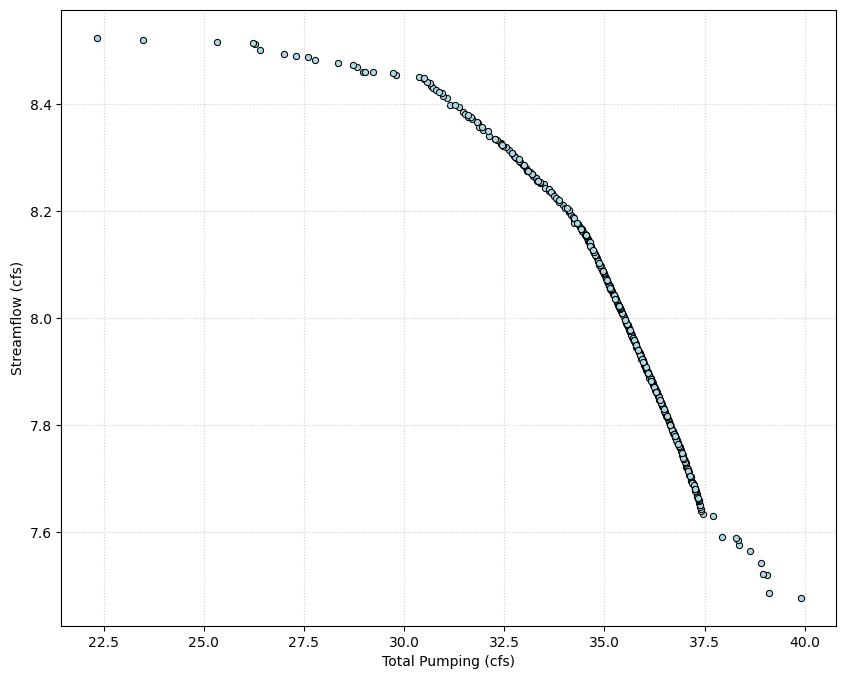

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(new_df["Total Pumping (cfs)"], new_df["Streamflow (cfs)"], marker="o", s=20, c="lightblue", edgecolors="black", linewidths=0.75)
ax.set_xlabel("Total Pumping (cfs)")
ax.set_ylabel("Streamflow (cfs)")
ax.grid(linestyle=":", alpha=0.6)
plt.show()

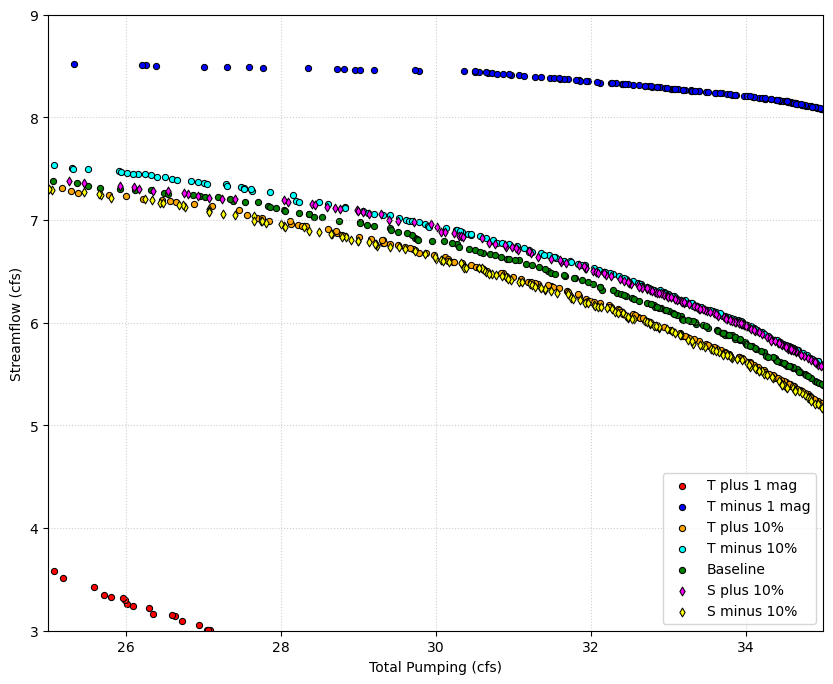

In [15]:
plusT1mag = pd.read_csv('depletion_q_Tplus1mag_0.0_1.0_0.01_tradeoff.csv')
minusT1mag = pd.read_csv('depletion_q_Tmin1mag_0.0_1.0_0.01_tradeoff.csv')
plusT10per = pd.read_csv('depletion_q_Tplus10per_0.0_1.0_0.01_tradeoff.csv')
minusT10per = pd.read_csv('depletion_q_Tmin10per_0.0_1.0_0.01_tradeoff.csv')
baseline = pd.read_csv('depletion_q_baseline_0.0_1.0_0.01_tradeoff.csv')
plusS10per = pd.read_csv('depletion_q_Splus10per_0.0_1.0_0.01_tradeoff.csv')
minusS10per = pd.read_csv('depletion_q_Smin10per_0.0_1.0_0.01_tradeoff.csv')

plt.figure(figsize=(10, 8))
plt.scatter(plusT1mag["Total Pumping (cfs)"], plusT1mag["Streamflow (cfs)"], marker="o", s=20, c="red", edgecolors="black", linewidths=0.75, label='T plus 1 mag')
plt.scatter(minusT1mag["Total Pumping (cfs)"], minusT1mag["Streamflow (cfs)"], marker="o", s=20, c="blue", edgecolors="black", linewidths=0.75, label='T minus 1 mag')
plt.scatter(plusT10per["Total Pumping (cfs)"], plusT10per["Streamflow (cfs)"], marker="o", s=20, c="orange", edgecolors="black", linewidths=0.75, label='T plus 10%')
plt.scatter(minusT10per["Total Pumping (cfs)"], minusT10per["Streamflow (cfs)"], marker="o", s=20, c="cyan", edgecolors="black", linewidths=0.75, label='T minus 10%')
plt.scatter(baseline["Total Pumping (cfs)"], baseline["Streamflow (cfs)"], marker="o", s=20, c="green", edgecolors="black", linewidths=0.75, label='Baseline')
plt.scatter(plusS10per["Total Pumping (cfs)"], plusS10per["Streamflow (cfs)"], marker="d", s=20, c="magenta", edgecolors="black", linewidths=0.75, label='S plus 10%')
plt.scatter(minusS10per["Total Pumping (cfs)"], minusS10per["Streamflow (cfs)"], marker="d", s=20, c="yellow", edgecolors="black", linewidths=0.75, label='S minus 10%')
plt.xlabel("Total Pumping (cfs)")
plt.ylabel("Streamflow (cfs)")
plt.grid(linestyle=":", alpha=0.6)
plt.xlim(25, 35)
plt.ylim(3, 9)
plt.legend()